In [1]:
import sys
from pathlib import Path
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as path_effects
from scipy.spatial import KDTree
# import scienceplots

# plt.style.use(['science'])

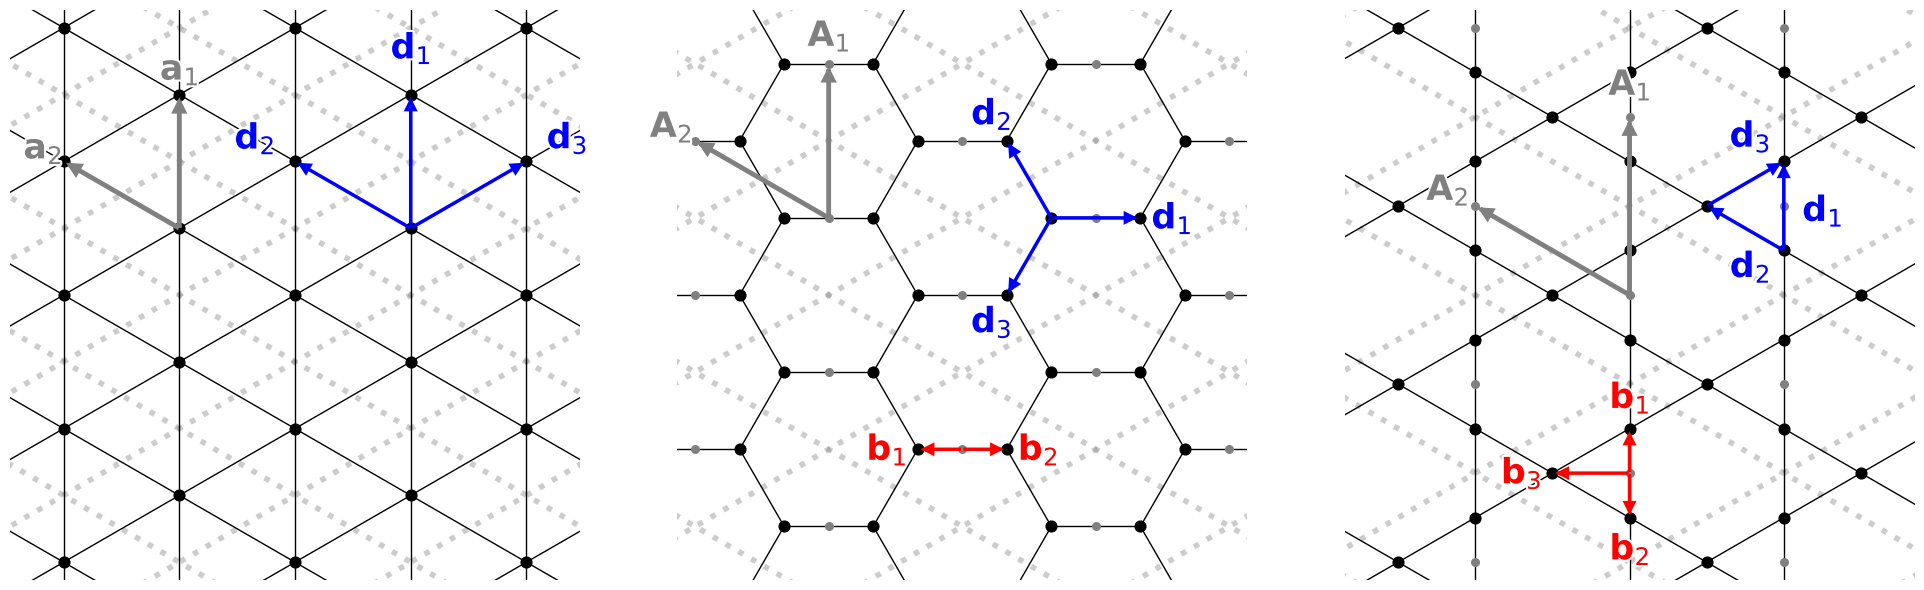

In [11]:
a_tri = E9c.a_sw_tri
a_hc = E9c.a_lw_hex
a_kag = E9c.a_sw_tri

def add_arrow(ax, start, end, color='k', lw=2.0, mutation_scale=15,
              label='', text_offset=(0,0)):
    """Utility to add a sharp FancyArrowPatch with an optional outlined label."""
    arrow = FancyArrowPatch(
        start, end, 
        color=color, 
        lw=lw,
        arrowstyle='-|>', 
        mutation_scale=mutation_scale,
        joinstyle='miter',
        capstyle='projecting',
        zorder=6 
    )
    ax.add_patch(arrow)
    if label:
        pos = end + np.array(text_offset)
        # White stroke effect guarantees labels are readable even if they cross a black bond
        text_outline = [path_effects.withStroke(linewidth=3, foreground='white')]
        ax.text(pos[0], pos[1], label, color=color, fontsize=25, ha='center', va='center', 
                zorder=7, path_effects=text_outline)

def draw_grid_lines(ax, v2, v3, grid_range, color='gray'):
    """Draws continuous dashed grid lines along v2 and v3 to define unit cells."""
    min_idx = min(grid_range)
    max_idx = max(grid_range)
    
    for i in grid_range:
        # Lines parallel to v3 (shifting along v2)
        start1 = (i - 0.5) * v2 + (min_idx - 0.5) * v3
        end1 = (i - 0.5) * v2 + (max_idx + 0.5) * v3
        ax.plot([start1[0], end1[0]], [start1[1], end1[1]], 
                color=color, linestyle=':', lw=4, alpha=0.4, zorder=1)
        
        # Lines parallel to v2 (shifting along v3)
        start2 = (min_idx - 0.5) * v2 + (i - 0.5) * v3
        end2 = (max_idx + 0.5) * v2 + (i - 0.5) * v3
        ax.plot([start2[0], end2[0]], [start2[1], end2[1]], 
                color=color, linestyle=':', lw=4, alpha=0.4, zorder=1)

def plot_lattice(ax, lat_vecs, basis_vectors, d_vectors, lat_label, a_scale, d_starts,
                 lat_cell=(0,0), basis_cell=(-1,-1), d_cell=(0,0), 
                 b_text_offset=(None, None, None), d_text_offset=(None, None, None)):
    """General function to plot the lattice sites, cells, and uniquely placed vectors."""
    ax.set_aspect('equal')
    ax.axis('off')
    
    v1, v2, v3 = lat_vecs
    
    grid_range = range(-6, 7) 
    cell_centers = []
    all_sites = []

    # Generate lattice space spanned exclusively by v2 and v3
    for i in grid_range:
        for j in grid_range:
            center = i * v2 + j * v3
            cell_centers.append(center)
            for r in basis_vectors:
                all_sites.append(center + r)

    cell_centers = np.array(cell_centers)
    all_sites = np.array(all_sites)

    # 1. Bonds
    tree = KDTree(all_sites)
    bond_length = np.linalg.norm(d_vectors[0]) * 1.05 
    pairs = tree.query_pairs(r=bond_length)
    for (i, j) in pairs:
        p1 = all_sites[i]
        p2 = all_sites[j]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='black', lw=1.0, zorder=2)

    # 2. Continuous Unit Cell Grid (along v2 and v3)
    draw_grid_lines(ax, v2, v3, grid_range, color='gray')

    # 3. Cell Centers
    ax.scatter(cell_centers[:, 0], cell_centers[:, 1], color='gray', s=30, zorder=3)

    # 4. Lattice Sites
    ax.scatter(all_sites[:, 0], all_sites[:, 1], color='black', s=60, zorder=4)

    # 5. Arrows
    # Resolve the exact origin anchor for the three different groups of arrows
    lat_origin = lat_cell[0] * v1 + lat_cell[1] * v2
    basis_origin = basis_cell[0] * v1 + basis_cell[1] * v2
    d_origin = d_cell[0] * v1 + d_cell[1] * v2

    # Lattice Vectors (Grey) - Showing v1 and v2
    add_arrow(ax, lat_origin, lat_origin + v1, color='gray', lw=3.5, 
              label=rf'${lat_label}_1$', text_offset=v1*0.18)
    add_arrow(ax, lat_origin, lat_origin + v2, color='gray', lw=3.5, 
              label=rf'${lat_label}_2$', text_offset=v2*0.18)

    # Basis Vectors (Red)
    if len(basis_vectors) > 1:
        for idx, r in enumerate(basis_vectors):
            offset = b_text_offset[idx] if b_text_offset[idx] is not None else r*0.7
            add_arrow(ax, basis_origin, basis_origin + r, color='red', lw=2.5, 
                      label=rf'$\mathbf{{b}}_{idx+1}$', text_offset=offset)

    # d-Vectors (Blue) - From explicit geometric starts based on draft
    for idx, d in enumerate(d_vectors):
        start_site = d_origin + basis_vectors[d_starts[idx]]
        end_site = start_site + d
        offset = d_text_offset[idx] if d_text_offset[idx] is not None else d * 0.35
        add_arrow(ax, start_site, end_site, color='blue', lw=2.5, 
                  label=rf'$\mathbf{{d}}_{idx+1}$', text_offset=offset)

    # Dynamic scaling based on their distinct lattice spacing
    limit = 3.2 * a_scale
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

# --- Triangular Lattice ---
lat_vecs_tri = [E9c.a1, E9c.a2, E9c.a3]
basis_tri = [np.array([0.0, 0.0])]
d_vecs_tri = [
    a_tri * np.array([0, 1]),
    a_tri * np.array([-np.sqrt(3)/2, 1/2]),
    a_tri * np.array([np.sqrt(3)/2, 1/2])
]
d_starts_tri = [0, 0, 0] # All start at the only basis site

# --- Honeycomb Lattice ---
lat_vecs_hc = [E9c.A1, E9c.A2, E9c.A3]
basis_hc = [
    a_hc * np.array([-1/2, 0]),
    a_hc * np.array([1/2, 0])
]
d_vecs_hc = [
    a_hc * np.array([1, 0]),
    a_hc * np.array([-1/2, np.sqrt(3)/2]),
    a_hc * np.array([-1/2, -np.sqrt(3)/2])
]
d_starts_hc = [0, 0, 0] # All start from b2 (right site) matching draft

# --- Kagome Lattice ---
lat_vecs_kag = [E9c.A1, E9c.A2, E9c.A3]
ddd = 0
basis_kag = [
    # a_kag * np.array([0, 1/2]),
    # a_kag * np.array([0, -1/2]),
    # a_kag * np.array([-np.sqrt(3)/2, 0])
    a_kag * np.array([-ddd, 1/2]),
    a_kag * np.array([-ddd, -1/2]),
    a_kag * np.array([-ddd-np.sqrt(3)/2, 0])
]
d_vecs_kag = [
    a_kag * np.array([0, 1]),
    a_kag * np.array([-np.sqrt(3)/2, 1/2]),
    a_kag * np.array([np.sqrt(3)/2, 1/2])
]
d_starts_kag = [1, 1, 2] # d1 from b2, d2 from b2, d3 from b3

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_lattice(axes[0], lat_vecs_tri, basis_tri, d_vecs_tri, lat_label=r'\mathbf{a}', 
             a_scale=a_tri/1.5, d_starts=d_starts_tri,
             lat_cell=(0,1), basis_cell=(-1,0), d_cell=(1,-1))

plot_lattice(axes[1], lat_vecs_hc, basis_hc, d_vecs_hc, lat_label=r'\mathbf{A}', 
             a_scale=a_hc, d_starts=d_starts_hc,
             lat_cell=(0,1), basis_cell=(-1,0), d_cell=(1,-1))

plot_lattice(axes[2], lat_vecs_kag, basis_kag, d_vecs_kag, lat_label=r'\mathbf{A}', 
             a_scale=a_kag, d_starts=d_starts_kag,
             lat_cell=(0,0), basis_cell=(-1,0), d_cell=(1,-1),
             b_text_offset = (None,
                              None,
                              a_kag * np.array([-0.35, 0])),
             d_text_offset = (-0.15 * E9c.A1 - 0.25 * E9c.A2,
                              -0.2 * E9c.A1 - 0.28 * E9c.A2,
                              0.25 * E9c.A1 - 0.22 * E9c.A3))

fig.tight_layout()
fig.subplots_adjust(wspace=0.05)

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
file_full_path = Path(thesis_fig_path, "lattice_real_space.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches = 'tight')